# KLIA flight delays: EDA, model selection and tuning (incremental learning)

**Workflow:**
1. Load data, explore it
2. On a **subset** of the data: compare single incremental models -> pick a **benchmark**
3. On the **same subset**: try **ensembles** (bagging, random subspace) -> compare to the benchmark
4. Pick the overall best model/ensemble, then **tune its hyperparameters with Optuna** -- still on the subset only
5. Train the **tuned model on the FULL dataset** (chunked `partial_fit` calls, exactly like production)
6. Save the trained bundle and **promote it in the MLflow Model Registry**

All candidates use **incremental learning**: each is updated with `partial_fit` on a CHUNK of rows at a
time (never one row at a time, never refit from scratch). This matches exactly how the production
update job works: one `partial_fit` call per batch of new flights.

**Demo data warning:** if `DATABASE_URL` is not in `.env`, this runs on synthetic data and will NOT
save a model choice at the end. Connect your Neon database and re-run for a real result.

In [1]:
import os, time, json, warnings, gzip, pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mlflow
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.figsize": (10, 3.6), "axes.grid": True, "grid.alpha": .25})

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(ROOT)

env_file = ROOT / ".env"
if env_file.exists():
    for line in env_file.read_text(encoding="utf-8").splitlines():
        line = line.strip()
        if not line or line.startswith("#") or "=" not in line:
            continue
        k, _, v = line.partition("=")
        os.environ.setdefault(k.strip(), v.strip().strip('"').strip("'"))

from klia.config import load_config, database_url, artifacts_dir
from klia.etl.validate import clean
from klia.features.state import FeatureState
from klia.pipeline import feature_stream
from klia.model import incremental as inc
from sklearn.metrics import roc_auc_score, log_loss, brier_score_loss

cfg = load_config()
ECFG = cfg["eda"]

MLFLOW_DB = ROOT / "mlflow.db"
mlflow.set_tracking_uri(f"sqlite:///{MLFLOW_DB}")
mlflow.set_experiment("klia-flight-delay")
print(f"MLflow tracking: {MLFLOW_DB}")
print("Browse: mlflow ui --backend-store-uri sqlite:///mlflow.db   (http://127.0.0.1:5000)")

/mnt/c/Users/owner/Downloads/klia-mlops/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


MLflow tracking: /mnt/c/Users/owner/Downloads/klia-mlops/mlflow.db
Browse: mlflow ui --backend-store-uri sqlite:///mlflow.db   (http://127.0.0.1:5000)


## 1. Load data

In [2]:
url = database_url()
if url:
    from sqlalchemy import create_engine
    raw = pd.read_sql(
        f"SELECT * FROM {cfg['data']['table']} WHERE actual_departure IS NOT NULL ORDER BY id",
        create_engine(url))
    SOURCE = "Neon"
else:
    from klia.demo import make
    raw = make(20000)
    SOURCE = "DEMO (synthetic)"

print(f"source: {SOURCE} | rows: {len(raw):,} | columns: {list(raw.columns)}")
raw.head()

source: Neon | rows: 80,770 | columns: ['id', 'date', 'scheduled_departure', 'actual_departure', 'flight_number', 'destination', 'aircraft', 'airline', 'day_of_week', 'imported_at', 'temperature_2m', 'precipitation', 'wind_speed_10m', 'wind_speed_120m', 'wind_direction_10m', 'wind_direction_120m', 'wind_direction_180m', 'wind_gusts_10m', 'cloud_cover', 'cloud_cover_low', 'cloud_cover_mid', 'cloud_cover_high', 'weather_updated_at']


,id,date,scheduled_departure,actual_departure,flight_number,destination,aircraft,airline,day_of_week,imported_at,...,wind_speed_120m,wind_direction_10m,wind_direction_120m,wind_direction_180m,wind_gusts_10m,cloud_cover,cloud_cover_low,cloud_cover_mid,cloud_cover_high,weather_updated_at
0,1,2026-01-17,09:05:00,09:38:00,AK642,Da Nang,A320,AirAsia (WeAreAllChampions Livery),Saturday,2026-05-01 08:21:29.600208,...,NaN,72.0,NaN,NaN,13.0,98.0,2.0,2.0,98.0,2026-05-04 19:55:30.872569
1,2,2026-01-17,09:05:00,09:18:00,AK5136,Kota Kinabalu,A320,AirAsia,Saturday,2026-05-01 08:21:29.600208,...,NaN,72.0,NaN,NaN,13.0,98.0,2.0,2.0,98.0,2026-05-04 19:55:30.872569
2,3,2026-01-17,09:05:00,09:42:00,D7320,Chengdu,A333,AirAsia X,Saturday,2026-05-01 08:21:29.600208,...,NaN,72.0,NaN,NaN,13.0,98.0,2.0,2.0,98.0,2026-05-04 19:55:30.872569
3,4,2026-01-17,09:05:00,09:27:00,QZ321,Surabaya,A320,AirAsia,Saturday,2026-05-01 08:21:29.600208,...,NaN,72.0,NaN,NaN,13.0,98.0,2.0,2.0,98.0,2026-05-04 19:55:30.872569
4,5,2026-01-17,09:05:00,09:25:00,MH174,Mumbai,B738,Malaysia Airlines,Saturday,2026-05-01 08:21:29.600208,...,NaN,72.0,NaN,NaN,13.0,98.0,2.0,2.0,98.0,2026-05-04 19:55:30.872569


## 2. Data quality

In [3]:
ok, bad = clean(raw, cfg)
print(f"accepted {len(ok):,} | rejected {len(bad):,} ({len(bad)/max(len(raw),1):.2%})")
if len(bad):
    display(bad["reason"].value_counts().to_frame("rows"))
print("date range:", ok.sched_dt.min(), "->", ok.sched_dt.max())
print(f"delay rate (>= {cfg['data']['delay_threshold_minutes']} min): {ok.is_delayed.mean():.1%}")
ok[["delay_min"]].describe().T

accepted 80,758 | rejected 12 (0.01%)


,rows
reason,
implausible delay,12


date range: 2026-01-17 09:05:00 -> 2026-07-31 20:25:00
delay rate (>= 15 min): 61.3%


,count,mean,std,min,25%,50%,75%,max
delay_min,80758.0,27.689083,37.438109,-173.0,10.0,18.0,31.0,1335.0


## 3. Exploration

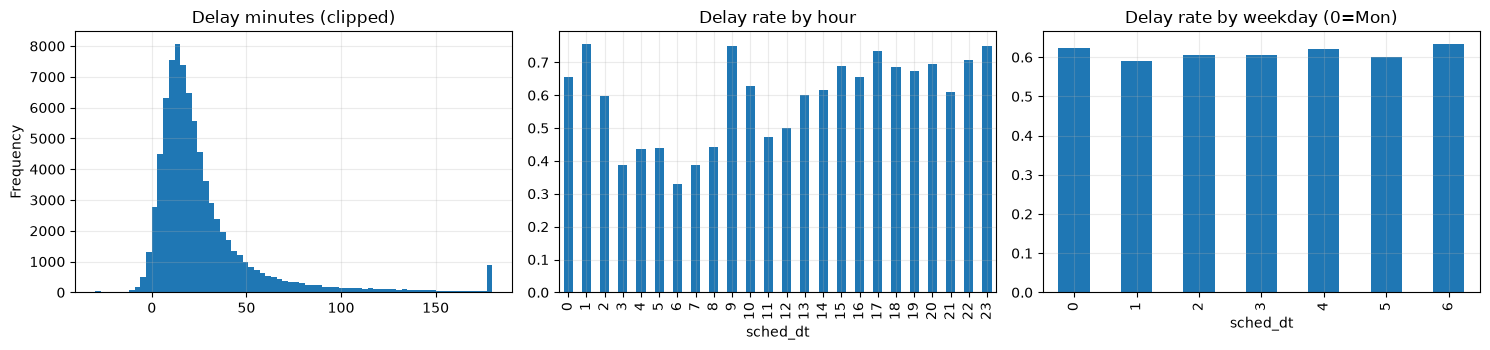

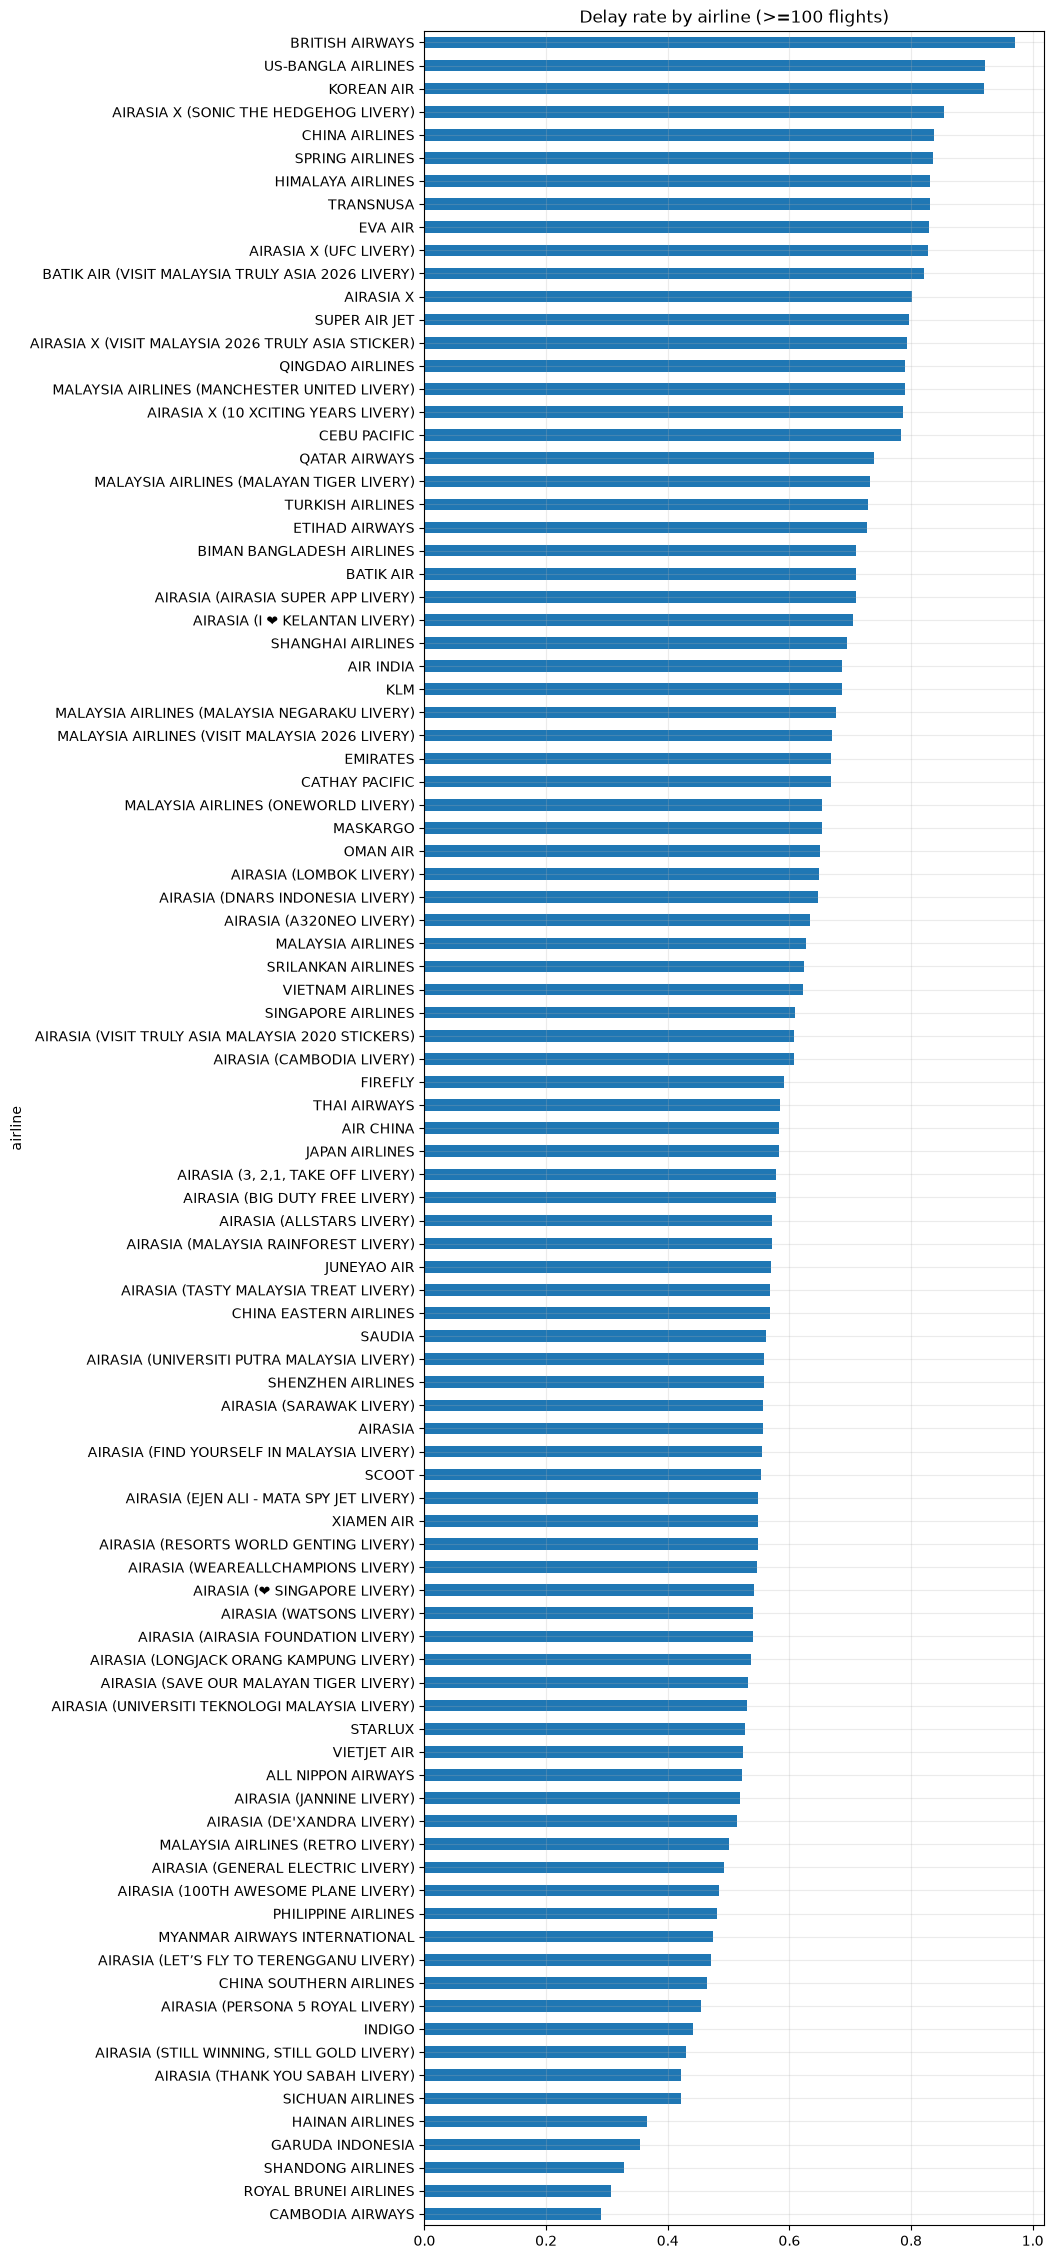

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(15, 3.6))
ok.delay_min.clip(-30, 180).plot.hist(bins=70, ax=ax[0], title="Delay minutes (clipped)")
ok.groupby(ok.sched_dt.dt.hour).is_delayed.mean().plot.bar(ax=ax[1], title="Delay rate by hour")
ok.groupby(ok.sched_dt.dt.dayofweek).is_delayed.mean().plot.bar(ax=ax[2], title="Delay rate by weekday (0=Mon)")
plt.tight_layout(); plt.show()

top = ok.groupby("airline").is_delayed.agg(["mean","count"]).query("count>=100").sort_values("mean")
top["mean"].plot.barh(figsize=(8, max(3,.3*len(top))), title="Delay rate by airline (>=100 flights)"); plt.show()

## 4. Build the subset for model comparison and tuning
We only use **the first `subset_fraction` of the (time-ordered) data** for sections 5-7. This keeps
comparison and tuning fast; the winner is retrained on the full dataset in section 8.

In [5]:
state_full = FeatureState(cfg)        # the REAL state, built once over all data, reused in section 8
X_full, y_full = feature_stream(ok, state_full)
y_full = np.array(y_full)
print(f"full dataset: {len(X_full):,} rows x {len(X_full[0])} features")

n_sub = max(2000, int(len(X_full) * ECFG["subset_fraction"]))
X_sub, y_sub = X_full[:n_sub], y_full[:n_sub]
BATCH = ECFG["batch_size"]
print(f"subset for comparison/tuning: {n_sub:,} rows ({ECFG['subset_fraction']:.0%} of data), "
     f"batch size {BATCH} ({n_sub // BATCH} batches)")

full dataset: 80,758 rows x 23 features
subset for comparison/tuning: 20,189 rows (25% of data), batch size 500 (40 batches)


## 5. Benchmark: compare single incremental models (subset only)
Each model is updated with `partial_fit` on one batch of `BATCH` rows at a time, scored on each
batch BEFORE learning from it (prequential), exactly like the production update job.

In [6]:
SINGLE_MODELS = {
    "sgd_log":   {},
    "sgd_hinge": {},
    "gnb":       {},
    "mlp":       {"hidden": 32},
    # Boosting models — each partial_fit adds n_iter trees via warm-start
    "xgb":       {"max_depth": 4, "eta": 0.1,       "n_iter": 20},
    "lgbm":      {"num_leaves": 31, "learning_rate": 0.1, "n_iter": 20},
    "catboost":  {"depth": 4, "learning_rate": 0.1,  "n_iter": 20},
}
WARMUP_BATCHES = 1

def evaluate(name, params, X, y, batch_size=BATCH, log_run=True, run_name=None):
    m = inc.build(name, params)
    t0 = time.time()
    p = inc.batch_prequential(m, X, y, batch_size=batch_size, warmup_batches=WARMUP_BATCHES)
    secs = time.time() - t0
    cut = batch_size * WARMUP_BATCHES
    s, yy = p[cut:], np.asarray(y[cut:])
    auc = roc_auc_score(yy, s) if yy.min() != yy.max() else float("nan")
    ll  = log_loss(yy, np.clip(s, 1e-6, 1-1e-6))
    bs  = brier_score_loss(yy, s)
    thr, f1 = inc.best_threshold(s, yy)
    mb = len(gzip.compress(pickle.dumps(m))) / 1e6
    row = {"model": run_name or name, "AUC": auc, "logloss": ll, "brier": bs, "best_F1": f1,
          "bundle_MB": mb, "ms_per_row": 1000*secs/len(y), "spec": {"name": name, "params": params}}
    if log_run:
        with mlflow.start_run(run_name=row["model"], nested=True):
            mlflow.log_params({"name": name, "params": str(params), "batch_size": batch_size})
            mlflow.log_metrics({k: round(v,4) for k,v in row.items() if isinstance(v,(int,float))})
    return row, m, p

benchmark_results = []
with mlflow.start_run(run_name="1_benchmark_single_models"):
    mlflow.log_params({"rows": n_sub, "batch_size": BATCH, "source": SOURCE})
    for name, params in SINGLE_MODELS.items():
        row, _, _ = evaluate(name, params, X_sub, y_sub)
        benchmark_results.append(row)
        print(f"  {name:12s} AUC {row['AUC']:.4f}  bundle {row['bundle_MB']:.2f} MB  {row['ms_per_row']:.3f} ms/row")

bench_df = pd.DataFrame(benchmark_results)
BENCHMARK = bench_df.loc[bench_df.AUC.idxmax()]
print(f"\nBENCHMARK: {BENCHMARK.model}  AUC {BENCHMARK.AUC:.4f}")
bench_df.drop(columns="spec").round(4).sort_values("AUC", ascending=False)

  sgd_log      AUC 0.5369  bundle 0.00 MB  0.061 ms/row
  sgd_hinge    AUC 0.5508  bundle 0.00 MB  0.021 ms/row
  gnb          AUC 0.6966  bundle 0.00 MB  0.021 ms/row
  mlp          AUC 0.5183  bundle 0.03 MB  0.028 ms/row
  xgb          AUC 0.6935  bundle 0.27 MB  0.332 ms/row
  lgbm         AUC 0.6582  bundle 0.71 MB  0.358 ms/row
  catboost     AUC 0.7037  bundle 0.14 MB  0.241 ms/row

BENCHMARK: catboost  AUC 0.7037


,model,AUC,logloss,brier,best_F1,bundle_MB,ms_per_row
6,catboost,0.7037,0.6435,0.2116,0.8042,0.1440,0.2414
2,gnb,0.6966,1.8638,0.2860,0.7757,0.0015,0.0205
4,xgb,0.6935,0.7019,0.2226,0.8015,0.2707,0.3323
5,lgbm,0.6582,1.0109,0.2608,0.7926,0.7143,0.3583
1,sgd_hinge,0.5508,5.8501,0.4235,0.6640,0.0011,0.0215
0,sgd_log,0.5369,5.8364,0.4237,0.6714,0.0011,0.0611
3,mlp,0.5183,0.9700,0.2906,0.7931,0.0294,0.0275


## 6. Try ensembles (subset only)
Two incremental ensemble kinds, built from the base models above:
- **Bagging** -- each member trains on a bootstrap resample of every batch
- **Random subspace** -- each member trains on a random subset of features

In [7]:
ENSEMBLE_CANDIDATES = {
    "bag_sgd_log":    {"n_estimators": 7},
    "bag_sgd_hinge":  {"n_estimators": 7},
    "rsub_sgd_log":   {"n_estimators": 7, "subspace_frac": 0.7},
    "bag_mlp":        {"n_estimators": 5},
    # Boosting ensembles
    "bag_xgb":        {"n_estimators": 5, "n_iter": 20},
    "bag_lgbm":       {"n_estimators": 5, "n_iter": 20},
    "rsub_xgb":       {"n_estimators": 5, "subspace_frac": 0.7, "n_iter": 20},
}
ensemble_results = []
with mlflow.start_run(run_name="2_ensembles"):
    mlflow.log_params({"rows": n_sub, "batch_size": BATCH})
    for name, params in ENSEMBLE_CANDIDATES.items():
        row, _, _ = evaluate(name, params, X_sub, y_sub)
        ensemble_results.append(row)
        print(f"  {name:16s} AUC {row['AUC']:.4f}  bundle {row['bundle_MB']:.2f} MB  {row['ms_per_row']:.3f} ms/row")

ens_df = pd.DataFrame(ensemble_results)
all_df = pd.concat([bench_df, ens_df], ignore_index=True)
display(all_df.drop(columns="spec").round(4).sort_values("AUC", ascending=False).reset_index(drop=True))

  bag_sgd_log      AUC 0.6088  bundle 0.00 MB  0.169 ms/row
  bag_sgd_hinge    AUC 0.6010  bundle 0.00 MB  0.149 ms/row
  rsub_sgd_log     AUC 0.5990  bundle 0.00 MB  0.170 ms/row
  bag_mlp          AUC 0.5790  bundle 0.14 MB  0.213 ms/row
  bag_xgb          AUC 0.7155  bundle 1.31 MB  1.290 ms/row
  bag_lgbm         AUC 0.6942  bundle 2.81 MB  1.615 ms/row
  rsub_xgb         AUC 0.7190  bundle 1.34 MB  1.298 ms/row


,model,AUC,logloss,brier,best_F1,bundle_MB,ms_per_row
0,rsub_xgb,0.7190,0.5928,0.1982,0.8078,1.3371,1.2980
1,bag_xgb,0.7155,0.6045,0.2012,0.8058,1.3058,1.2898
2,catboost,0.7037,0.6435,0.2116,0.8042,0.1440,0.2414
3,gnb,0.6966,1.8638,0.2860,0.7757,0.0015,0.0205
4,bag_lgbm,0.6942,0.7215,0.2084,0.8030,2.8064,1.6152
5,xgb,0.6935,0.7019,0.2226,0.8015,0.2707,0.3323
6,lgbm,0.6582,1.0109,0.2608,0.7926,0.7143,0.3583
7,bag_sgd_log,0.6088,1.0585,0.2336,0.8000,0.0028,0.1692
8,bag_sgd_hinge,0.6010,1.2025,0.2432,0.7986,0.0028,0.1489
9,rsub_sgd_log,0.5990,0.9683,0.2372,0.7996,0.0030,0.1695


## 7. Choose the overall best model or ensemble
Model size is **not** a selection criterion here -- it only matters later if you store the bundle in
Neon (capped at `registry.max_mb_neon`, default 400 MB). Storing it locally via MLflow's own
artifact store has no cap at all. We simply pick the **highest AUC**.

In [8]:
CHOSEN = all_df.loc[all_df.AUC.idxmax()]
print(f"CHOSEN: {CHOSEN.model}  (AUC {CHOSEN.AUC:.4f} on the {ECFG['subset_fraction']:.0%} subset)")
print(f"vs single-model benchmark {BENCHMARK.model}: {CHOSEN.AUC - BENCHMARK.AUC:+.4f} AUC")
CHOSEN_NAME, CHOSEN_PARAMS = CHOSEN.spec["name"], dict(CHOSEN.spec["params"])

CHOSEN: rsub_xgb  (AUC 0.7190 on the 25% subset)
vs single-model benchmark catboost: +0.0153 AUC


## 8. Tune hyperparameters with Optuna (subset only)
Still on the same subset used in sections 5-6 -- tuning on the full dataset would be slow and is
unnecessary, since the winning configuration is what gets retrained on the full data next.

In [9]:
def suggest(trial: optuna.Trial, base_name: str) -> dict:
    is_ensemble = base_name.startswith(("bag_", "rsub_"))
    real_base = base_name.split("_", 1)[1] if is_ensemble else base_name
    p = {}
    if is_ensemble:
        p["n_estimators"] = trial.suggest_int("n_estimators", 3, 15)
        if base_name.startswith("rsub_"):
            p["subspace_frac"] = trial.suggest_float("subspace_frac", 0.4, 0.95)
    if real_base in ("sgd_log", "sgd_hinge"):
        p["alpha"]   = trial.suggest_float("alpha", 1e-6, 1e-1, log=True)
        p["penalty"] = trial.suggest_categorical("penalty", ["l2", "l1", "elasticnet"])
    elif real_base == "gnb":
        p["var_smoothing"] = trial.suggest_float("var_smoothing", 1e-12, 1e-6, log=True)
    elif real_base == "mlp":
        p["hidden"] = trial.suggest_categorical("hidden", [16, 32, 64])
        p["alpha"]  = trial.suggest_float("alpha", 1e-6, 1e-2, log=True)
        p["lr"]     = trial.suggest_float("lr", 1e-4, 1e-1, log=True)
    elif real_base == "xgb":
        p["n_iter"]           = trial.suggest_int("n_iter", 10, 50)
        p["max_depth"]        = trial.suggest_int("max_depth", 2, 6)
        p["eta"]              = trial.suggest_float("eta", 0.01, 0.3, log=True)
        p["subsample"]        = trial.suggest_float("subsample", 0.6, 1.0)
        p["colsample_bytree"] = trial.suggest_float("colsample_bytree", 0.5, 1.0)
    elif real_base == "lgbm":
        p["n_iter"]            = trial.suggest_int("n_iter", 10, 50)
        p["num_leaves"]        = trial.suggest_int("num_leaves", 15, 63)
        p["learning_rate"]     = trial.suggest_float("learning_rate", 0.01, 0.3, log=True)
        p["min_child_samples"] = trial.suggest_int("min_child_samples", 10, 50)
        p["subsample"]         = trial.suggest_float("subsample", 0.6, 1.0)
    elif real_base == "catboost":
        p["n_iter"]        = trial.suggest_int("n_iter", 10, 50)
        p["depth"]         = trial.suggest_float("depth", 2, 6)
        p["learning_rate"] = trial.suggest_float("learning_rate", 0.01, 0.3, log=True)
        p["l2_leaf_reg"]   = trial.suggest_float("l2_leaf_reg", 1.0, 10.0, log=True)
    return p

N_TRIALS = ECFG["n_optuna_trials"]

with mlflow.start_run(run_name="3_optuna_tuning") as parent:
    mlflow.log_params({"model_type": CHOSEN_NAME, "n_trials": N_TRIALS, "rows": n_sub})

    def objective(trial):
        params = suggest(trial, CHOSEN_NAME)
        row, _, _ = evaluate(CHOSEN_NAME, params, X_sub, y_sub, log_run=False)
        with mlflow.start_run(run_name=f"trial_{trial.number}", nested=True):
            mlflow.log_params({**params, "trial": trial.number})
            mlflow.log_metrics({"auc": round(row["AUC"], 4), "bundle_mb": round(row["bundle_MB"], 2)})
        return row["AUC"]

    study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

    TUNED_PARAMS = study.best_params
    mlflow.log_params({f"best_{k}": v for k, v in TUNED_PARAMS.items()})
    mlflow.log_metric("best_auc", round(study.best_value, 4))

print(f"\nbest AUC: {study.best_value:.4f}  (was {CHOSEN.AUC:.4f} with defaults)")
print(f"tuned params: {TUNED_PARAMS}")

Best trial: 11. Best value: 0.743359: 100%|██████████| 30/30 [21:40<00:00, 43.34s/it]



best AUC: 0.7434  (was 0.7190 with defaults)
tuned params: {'n_estimators': 12, 'subspace_frac': 0.4392370463754463, 'n_iter': 10, 'max_depth': 4, 'eta': 0.05014815657222842, 'subsample': 0.6097719476980525, 'colsample_bytree': 0.7740818313139453}


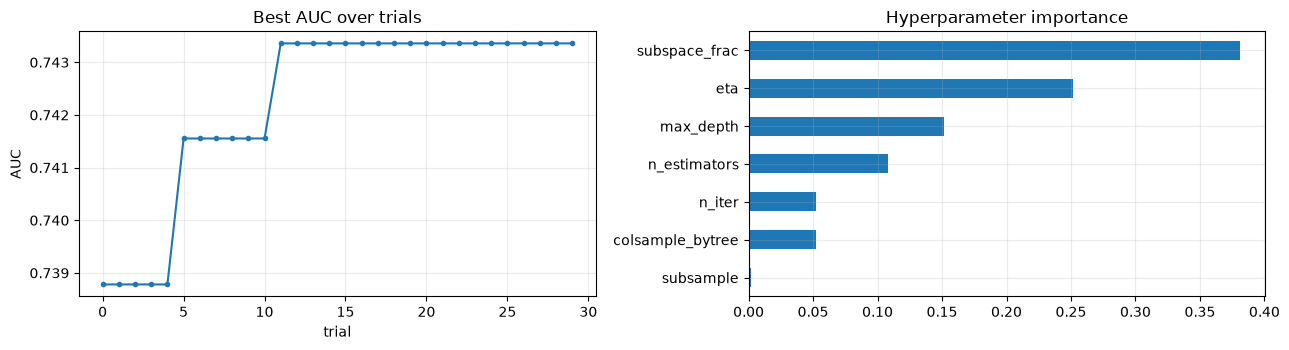

In [10]:
vals = [t.value for t in study.trials if t.value is not None]
best_so_far = np.maximum.accumulate(vals)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 3.6))
a1.plot(best_so_far, marker="."); a1.set_xlabel("trial"); a1.set_ylabel("AUC"); a1.set_title("Best AUC over trials")
imp = optuna.importance.get_param_importances(study)
pd.Series(imp).sort_values().plot.barh(ax=a2, title="Hyperparameter importance")
plt.tight_layout(); plt.show()

## 9. Train the tuned model on the FULL dataset
Same `partial_fit`-per-batch procedure as production, just run once over your entire history instead
of a daily slice of new rows. A fresh `FeatureState` is built alongside it (the one from section 4
already saw the full data in order, so we reuse it directly here instead of recomputing).

In [11]:
from klia.model.bundle import Bundle

final_model = inc.build(CHOSEN_NAME, TUNED_PARAMS)
t0 = time.time()
p_full = inc.batch_prequential(final_model, X_full, y_full.tolist(), batch_size=BATCH, warmup_batches=1)
print(f"trained on {len(X_full):,} rows in {time.time()-t0:.1f}s "
     f"({len(X_full)//BATCH} batches of {BATCH})")

cut = BATCH
full_auc = roc_auc_score(y_full[cut:], p_full[cut:])
print(f"full-dataset prequential AUC: {full_auc:.4f}")

thr, f1 = inc.best_threshold(p_full[cut:], y_full[cut:])
final_bundle = Bundle(model=final_model, state=state_full, threshold=thr,
                      meta={"chosen_by": "notebooks/01_model_selection_eda.ipynb",
                            "subset_auc": round(float(CHOSEN.AUC), 4),
                            "full_auc": round(float(full_auc), 4),
                            "tuned_params": TUNED_PARAMS, "rows": int(len(X_full))})
final_bundle.remember(p_full[cut:], y_full[cut:].tolist(), cfg["model"]["calibration_window"])
final_bundle.refresh_threshold()
print(f"decision threshold: {final_bundle.threshold:.2f}")

# Store drift reference for Evidently monitoring (used by every subsequent update job)
from klia.monitoring.drift import set_drift_reference
mon_cfg = cfg.get("monitoring", {})
set_drift_reference(
    final_bundle.meta, X_full,
    max_rows=mon_cfg.get("drift_reference_rows", 1000),
)
print(f"drift reference stored: "
      f"{len(final_bundle.meta['drift_reference']['data'])} rows × "
      f"{len(final_bundle.meta['drift_reference']['cols'])} features")

trained on 80,758 rows in 185.3s (161 batches of 500)
full-dataset prequential AUC: 0.7549
decision threshold: 0.29
drift reference stored: 1000 rows × 23 features


## 10. Save the final model and promote it in MLflow

- `artifacts/pretrained_bundle.gz` -- loaded automatically by `python -m klia.jobs.update --bootstrap`
- `artifacts/model_choice.json` -- a readable record of what was chosen
- Registered in the **MLflow Model Registry** (`klia-flight-delay`) and aliased **`champion`**

In [12]:
if SOURCE.startswith("DEMO"):
    print("DEMO data -- NOT saving or registering. Connect DATABASE_URL and re-run for a real model.")
else:
    bundle_bytes = final_bundle.dumps()
    bundle_path = artifacts_dir() / "pretrained_bundle.gz"
    bundle_path.write_bytes(bundle_bytes)
    print(f"saved {bundle_path}  ({len(bundle_bytes)/1e6:.2f} MB)")

    cap = cfg["registry"]["max_mb_neon"]
    if len(bundle_bytes) / 1e6 > cap:
        print(f"NOTE: this bundle is over the Neon cap ({cap} MB). It will still be used for "
             f"--bootstrap locally; to also push it through Neon's model_registry table during "
             f"routine updates, shrink the ensemble or store it locally instead (no cap).")

    choice = {"name": CHOSEN_NAME, "params": TUNED_PARAMS, "subset_auc": round(float(CHOSEN.AUC), 4),
             "full_auc": round(float(full_auc), 4), "rows": int(len(X_full)), "n_trials": N_TRIALS,
             "chosen_by": "notebooks/01_model_selection_eda.ipynb"}
    (artifacts_dir() / "model_choice.json").write_text(json.dumps(choice, indent=2))
    print(json.dumps(choice, indent=2))

    from klia.model.mlflow_pyfunc import log_and_register
    sample_input = pd.DataFrame([X_full[0]])
    with mlflow.start_run(run_name="4_final_model"):
        mlflow.log_params({"name": CHOSEN_NAME, **{f"param_{k}": v for k, v in TUNED_PARAMS.items()}})
        mlflow.log_metrics({"subset_auc": round(float(CHOSEN.AUC), 4), "full_auc": round(float(full_auc), 4)})
        version = log_and_register(str(bundle_path), sample_input)
    print(f"\nregistered 'klia-flight-delay' version {version}, aliased 'champion'")

print("\n--- Next steps ---")
print("1. python -m klia.jobs.update --bootstrap   # loads pretrained_bundle.gz, replays full history")
print("2. uvicorn klia.api.app:app --port 8000")
print("3. mlflow ui --backend-store-uri sqlite:///mlflow.db")

saved /mnt/c/Users/owner/Downloads/klia-mlops/artifacts/pretrained_bundle.gz  (6.79 MB)
{
  "name": "rsub_xgb",
  "params": {
    "n_estimators": 12,
    "subspace_frac": 0.4392370463754463,
    "n_iter": 10,
    "max_depth": 4,
    "eta": 0.05014815657222842,
    "subsample": 0.6097719476980525,
    "colsample_bytree": 0.7740818313139453
  },
  "subset_auc": 0.719,
  "full_auc": 0.7549,
  "rows": 80758,
  "n_trials": 30,
  "chosen_by": "notebooks/01_model_selection_eda.ipynb"
}


2026/10/03 16:10:04 WARNING mlflow.pyfunc: Passing a Python object as `python_model` causes it to be serialized using CloudPickle, it requires exercising caution as Python object serialization mechanisms may execute arbitrary code during deserialization.Consider using a file path (str or Path) instead. See https://mlflow.org/docs/latest/ml/model/models-from-code/ for details.
2026/10/03 16:10:04 INFO mlflow.pyfunc: Inferring model signature from input example
Registered model 'klia-flight-delay' already exists. Creating a new version of this model...
Created version '2' of model 'klia-flight-delay'.



registered 'klia-flight-delay' version 2, aliased 'champion'

--- Next steps ---
1. python -m klia.jobs.update --bootstrap   # loads pretrained_bundle.gz, replays full history
2. uvicorn klia.api.app:app --port 8000
3. mlflow ui --backend-store-uri sqlite:///mlflow.db
